In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [12]:
# ----------------------------
# Dataset CIFAR-10
# ----------------------------
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print("Train images:", x_train.shape)  # (50000, 32, 32, 3)
print("Train labels:", y_train.shape)  # (50000, 1)
print("Test  images:", x_test.shape)   # (10000, 32, 32, 3)
print("Test  labels:", y_test.shape)   # (10000, 1)

# labels: (N,1) -> (N,)
y_train = y_train.reshape(-1)
y_test  = y_test.reshape(-1)

# Normalizzazione 0-255 -> 0-1
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)

Train images: (50000, 32, 32, 3)
Train labels: (50000, 1)
Test  images: (10000, 32, 32, 3)
Test  labels: (10000, 1)
Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


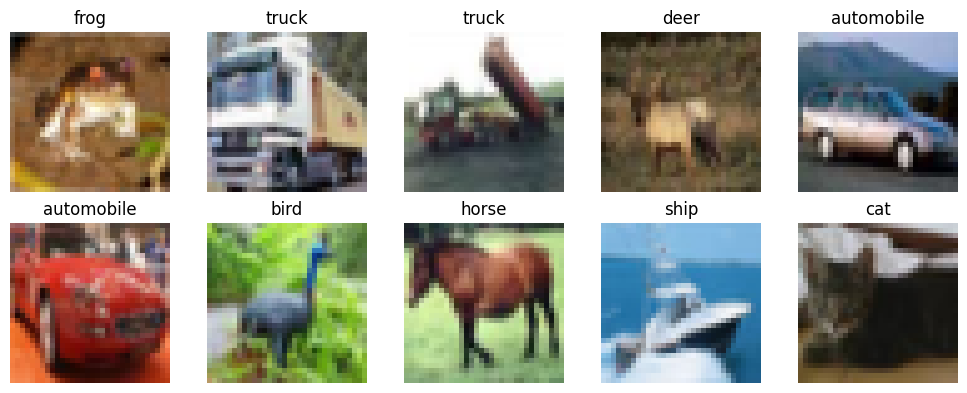

In [4]:
#  10 esempi
class_names = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [5]:
#  Modello CNN
model = keras.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ----------------------------
#  Compile
# ----------------------------
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# ----------------------------
#  Callbacks: EarlyStopping + ModelCheckpoint
# ----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",          # guardo la loss di validation
    patience=3,                  # se per 3 epoche non migliora -> stop
    restore_best_weights=True    # rimette i pesi migliori in RAM
)

checkpoint = ModelCheckpoint(
    filepath="best_cifar10_model.keras",  # file salvato su disco
    monitor="val_loss",
    save_best_only=True,                 # salva solo se migliora
    verbose=1
)

# ----------------------------
#  Fit
# ----------------------------
history = model.fit(
    x_train, y_train,
    epochs=50,                 # mettiamo alto, tanto early stopping fermerà prima
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print("\nChiavi history:", history.history.keys())

Epoch 1/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.3050 - loss: 1.8703
Epoch 1: val_loss improved from inf to 1.30262, saving model to best_cifar10_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 92s 255ms/step - accuracy: 0.3052 - loss: 1.8697 - val_accuracy: 0.5442 - val_loss: 1.3026
Epoch 2/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.5271 - loss: 1.3134
Epoch 2: val_loss improved from 1.30262 to 1.09150, saving model to best_cifar10_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 90s 255ms/step - accuracy: 0.5271 - loss: 1.3133 - val_accuracy: 0.6158 - val_loss: 1.0915
Epoch 3/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.6048 - loss: 1.1174
Epoch 3: val_loss improved from 1.09150 to 0.95807, saving model to best_cifar10_model.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 89s 252ms/step - accuracy: 0.6049 - loss: 1.1174 - val_accuracy: 0.6684 - val_loss: 0.9581
Epoch 4/50
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.6502 - loss: 0.9920
Epoch 4: val_

In [7]:
# ----------------------------
#  Evaluate sul test (modello in RAM)
# ----------------------------
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print("\nTEST (model in RAM):")
print("test_loss =", test_loss)
print("test_acc  =", test_acc)


TEST (model in RAM):
test_loss = 0.7595134377479553
test_acc  = 0.7397000193595886


In [8]:
# ----------------------------
#  Carico il best model dal file e rivaluto
# ----------------------------
best_model = keras.models.load_model("best_cifar10_model.keras")
best_test_loss, best_test_acc = best_model.evaluate(x_test, y_test, verbose=0)

print("\nTEST (BEST model da file):")
print("best_test_loss =", best_test_loss)
print("best_test_acc  =", best_test_acc)


TEST (BEST model da file):
best_test_loss = 0.7595134377479553
best_test_acc  = 0.7397000193595886


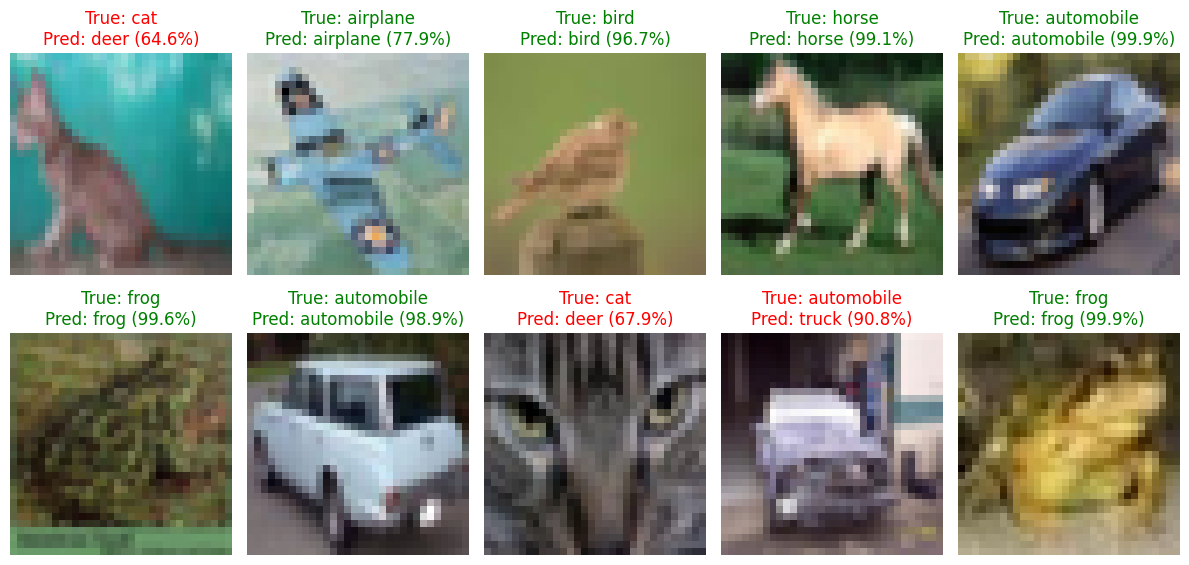

In [9]:
#  Predizioni su 10 immagini test
indices = np.random.choice(len(x_test), size=10, replace=False)

plt.figure(figsize=(12, 6))
for i, idx in enumerate(indices):
    img = x_test[idx]
    true_label = y_test[idx]

    pred = model.predict(img[np.newaxis, ...], verbose=0)[0]
    pred_label = int(np.argmax(pred))
    confidence = float(pred[pred_label] * 100)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    color = "green" if pred_label == true_label else "red"
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.1f}%)",
              color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

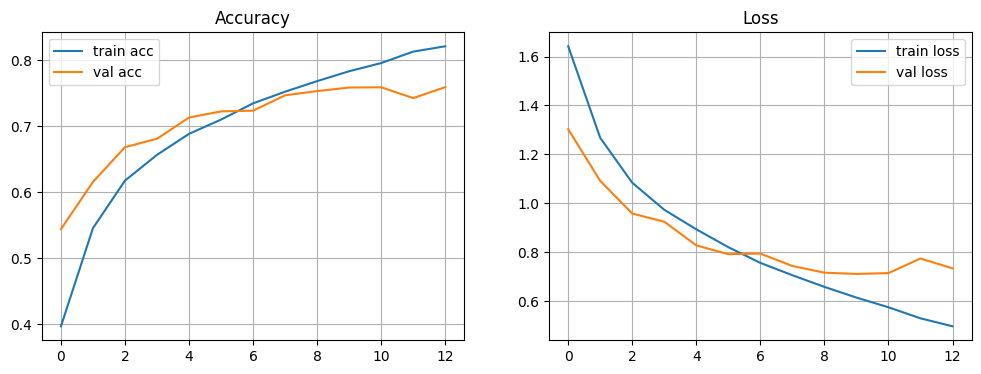


File salvato: best_cifar10_model.keras


In [10]:
# ----------------------------
#  Grafici training (loss / acc)
# ----------------------------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train acc")
plt.plot(history.history["val_accuracy"], label="val acc")
plt.title("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.show()

print("\nFile salvato:", "best_cifar10_model.keras")